# Avance 5: Modelo Final

**Proyecto integrador** — conjunto de datos **InHARD**.
### AI Co-Pilot for the Production Floor

**Equipo #56:** Landy Haydee Schlebach Osorio, Carlos Pano Hernández, Carlos Fernando Del Castillo Rey

**Sponsor:** Dr. Jacobo Eluani

**Asesor Académico**: Dr. Gerardo Camacho

La hipótesis es simple: en producción real, la inactividad dura 30-120 segundos — varios clips consecutivos. Un clip activo aislado que accidentalmente supera el umbral nunca debería disparar una alerta. Si revisamos los últimos k clips antes de decidir, eliminamos esas falsas alarmas sin afectar la detección de períodos reales de inactividad.

Evaluamos varios métodos de suavizado y comparamos cuál maximiza el F1.


# 1. Importar Librerías

In [8]:
import cv2
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
warnings.filterwarnings("ignore")

import torch
from transformers import AutoModel, AutoVideoProcessor
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              roc_auc_score, precision_recall_curve,
                              classification_report)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Device: {DEVICE}")


Device: mps


# 2. Configuración
Definimos los parámetros clave para la ejecución.

### Participant
P05 es el participante de InHARD con el que trabajamos. Tiene 77 clips de "No action", de los cuales reservamos 8 para evaluación y usamos los 69 restantes para construir el prototipo de inactividad.

### Embeddings
Usamos embeddings de referencia calculados en experimentos previos: 112 clips, 14 clases de InHARD, 1024 dimensiones cada uno. A partir de estos calculamos los prototipos de las 14 clases.

### Cache
El notebook guarda los embeddings en local la primera vez que los calcula. Las corridas siguientes los cargan directamente, evitando recalcular.

In [9]:
from pathlib import Path

NB10_EMBEDDINGS = Path("../outputs/10_action_id_v2/embeddings_v2.npy")
NB10_LABELS     = Path("../outputs/10_action_id_v2/labels_v2.npy")
INHARD_ROOT     = Path(
    "/Users/landyschlebach/Dataset In Hard/01-InHARD.7z/Segmented/RGBSegmented"
)

PARTICIPANT   = "P05"
IDLE_CLASS    = "No action"
N_FRAMES      = 16
N_EVAL_IDLE   = 8
N_EVAL_ACTIVE = 26

OUTPUTS    = Path("outputs/22_temporal_smoothing")
OUTPUTS.mkdir(parents=True, exist_ok=True)
CACHE_FILE = OUTPUTS / "embeddings_cache.npz"

print(f"Ruta InHARD:                         {INHARD_ROOT}")
print(f"Participante de referencia:          {PARTICIPANT}")
print(f"Clase de inactividad:                {IDLE_CLASS}")
print(f"Frames por embedding:                {N_FRAMES}")
print(f"Clips reservados para evaluación:    {N_EVAL_IDLE} idle + {N_EVAL_ACTIVE} active")
print(f"Cache:                               {CACHE_FILE}")


Ruta InHARD:                         /Users/landyschlebach/Dataset In Hard/01-InHARD.7z/Segmented/RGBSegmented
Participante de referencia:          P05
Clase de inactividad:                No action
Frames por embedding:                16
Clips reservados para evaluación:    8 idle + 26 active
Cache:                               outputs/22_temporal_smoothing/embeddings_cache.npz


# 3. Funciones Core

`crop_single_view()` extrae la vista izquierda del mosaico de 3 cámaras de InHARD. Usamos esta vista porque es la misma con la que se calcularon los embeddings de referencia en experimentos previos. Cualquier otra vista produciría embeddings en un espacio diferente, haciendo que la comparación con los prototipos no tenga sentido.

`load_clip_frames()` carga N frames uniformemente espaciados de un clip. Con N=16 y clips de ~5 segundos a 25fps, tomamos un frame aproximadamente cada 8 frames — suficiente para capturar la secuencia completa de la acción sin procesar frames redundantes.


In [10]:
def crop_single_view(frame_bgr):
    # Vista izquierda del mosaico InHARD — tercio izquierdo del frame
    H, W = frame_bgr.shape[:2]
    return cv2.resize(frame_bgr[:, :W//3, :], (224, 224))

def load_clip_frames(clip_path, n=N_FRAMES):
    cap   = cv2.VideoCapture(str(clip_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total == 0:
        cap.release()
        return []
    idx    = np.linspace(0, total-1, n, dtype=int)
    frames = []
    for i in idx:
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ret, f = cap.read()
        if ret:
            frames.append(crop_single_view(f))
    cap.release()
    return frames

# 4. V-JEPA2

Cargamos el modelo con sus pesos congelados. "Congelado" significa que sus parámetros nunca se modifican durante este proceso — Meta lo entrenó con millones de videos y nosotros solo lo usamos para extraer embeddings. El modelo recibe 16 frames de 224x224 píxeles y devuelve 1024 números que describen el movimiento observado.

In [11]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

MODEL_ID = "facebook/vjepa2-vitl-fpc16-256-ssv2"
print(f"Cargando {MODEL_ID}...")

vj_proc  = AutoVideoProcessor.from_pretrained(MODEL_ID)
vj_model = AutoModel.from_pretrained(MODEL_ID).to(DEVICE).eval()

print(f"V-JEPA2 listo en {DEVICE}.")

def embed_clip(frames_bgr):
    # Recibe lista de frames BGR 224x224, devuelve embedding L2-normalizado (1024,)
    if not frames_bgr:
        return None
    try:
        rgb = [cv2.cvtColor(f, cv2.COLOR_BGR2RGB) for f in frames_bgr]
        inp = vj_proc(list(np.stack(rgb, 0)), return_tensors="pt")
        inp = {k: v.to(DEVICE) for k, v in inp.items()}
        with torch.inference_mode():
            out = vj_model(**inp)
        if hasattr(out, "last_hidden_state"):
            raw = out.last_hidden_state.mean(dim=1).squeeze(0)
        else:
            raw = out.pooler_output.squeeze(0)
        emb  = raw.cpu().numpy().astype(np.float32)
        norm = np.linalg.norm(emb)
        return emb / (norm + 1e-8) if norm > 1e-8 else emb
    except Exception as e:
        return None


Cargando facebook/vjepa2-vitl-fpc16-256-ssv2...


Loading weights:   0%|          | 0/587 [00:00<?, ?it/s]

[transformers] VJEPA2Model LOAD REPORT from: facebook/vjepa2-vitl-fpc16-256-ssv2
Key                                                              | Status     |  | 
-----------------------------------------------------------------+------------+--+-
pooler.self_attention_layers.{0, 1, 2}.self_attn.k_proj.bias     | UNEXPECTED |  | 
pooler.self_attention_layers.{0, 1, 2}.mlp.fc2.bias              | UNEXPECTED |  | 
pooler.self_attention_layers.{0, 1, 2}.self_attn.v_proj.bias     | UNEXPECTED |  | 
pooler.self_attention_layers.{0, 1, 2}.self_attn.out_proj.weight | UNEXPECTED |  | 
pooler.self_attention_layers.{0, 1, 2}.mlp.fc2.weight            | UNEXPECTED |  | 
pooler.self_attention_layers.{0, 1, 2}.self_attn.k_proj.weight   | UNEXPECTED |  | 
pooler.cross_attention_layer.cross_attn.q_proj.bias              | UNEXPECTED |  | 
pooler.cross_attention_layer.cross_attn.q_proj.weight            | UNEXPECTED |  | 
pooler.self_attention_layers.{0, 1, 2}.self_attn.out_proj.bias   | UNEXPECTED |

V-JEPA2 listo en mps.


# 5. Prototipos

Cargamos los embeddings calculados en experimentos previos y construimos los prototipos de las 14 clases de InHARD. El prototipo de cada clase es el promedio de los embeddings de todos los clips de esa clase — el "retrato tipo" de cómo luce ese movimiento según V-JEPA2.

Usamos el prototipo de "No action" como referencia base. Más adelante lo complementaremos con uno específico de P05.


In [12]:
X_ref  = np.load(NB10_EMBEDDINGS).astype(np.float32)
y_ref  = np.load(NB10_LABELS)
norms  = np.linalg.norm(X_ref, axis=1, keepdims=True)
X_ref  = X_ref / (norms + 1e-8)

class_names = sorted(set(y_ref.tolist()))

def make_proto(emb_list):
    stack = np.stack(emb_list).mean(axis=0)
    norm  = np.linalg.norm(stack)
    return stack / (norm + 1e-8)

protos_nb10 = {cls: make_proto([X_ref[i] for i in np.where(y_ref == cls)[0]])
               for cls in class_names}

proto_idle_nb10   = protos_nb10[IDLE_CLASS]
active_classes    = [c for c in class_names if c != IDLE_CLASS]
proto_active_nb10 = make_proto([protos_nb10[c] for c in active_classes])

idle_mask = y_ref == IDLE_CLASS
sim_ref   = X_ref @ proto_idle_nb10
gap_ref   = sim_ref[idle_mask].mean() - sim_ref[~idle_mask].mean()

print(f"Prototipos cargados: {len(protos_nb10)} clases")
print(f"Gap de separabilidad en espacio: {gap_ref:.4f}")


Prototipos cargados: 14 clases
Gap de separabilidad en espacio: 0.0200


# 6. Secuencia de Evaluación

Separamos los clips de P05 en dos grupos sin mezclarlos: los que usaremos para construir los prototipos y los que reservamos para evaluar. Esto es fundamental — si evaluáramos con los mismos clips que usamos para construir el prototipo, el sistema parecería funcionar mejor de lo que realmente funciona.

La separación:
- 69 clips "No action" → construir proto_idle_P05
- 8 clips "No action"  → evaluación (estos son el GT_IDLE)
- 26 clips "Assemble system" → evaluación (activos)


In [13]:
idle_dir   = INHARD_ROOT / "No action"
active_dir = INHARD_ROOT / "Assemble system"

def get_clips(folder, pid, max_n=9999):
    clips = sorted(folder.glob(f"{pid}_*.mp4"))
    if not clips:
        clips = sorted(folder.rglob(f"{pid}_*.mp4"))
    return clips[:max_n]

all_idle   = get_clips(idle_dir,   PARTICIPANT)
all_active = get_clips(active_dir, PARTICIPANT)

eval_idle      = all_idle[:N_EVAL_IDLE]
proto_idle_c   = all_idle[N_EVAL_IDLE:]
eval_active    = all_active[:N_EVAL_ACTIVE]
proto_active_c = all_active[N_EVAL_ACTIVE:]

eval_sequence = ([(c, "active") for c in eval_active[:20]] +
                 [(c, "idle")   for c in eval_idle]         +
                 [(c, "active") for c in eval_active[20:26]])

gt_bin = np.array([1 if l == "idle" else 0 for _, l in eval_sequence])

print(f"Clips P05 - 'No action':       {len(all_idle)} total  ({len(proto_idle_c)} para proto + {len(eval_idle)} para eval)")
print(f"lips P05 - 'Assemble system': {len(all_active)} total  ({len(proto_active_c)} para proto + {len(eval_active)} para eval)")
print(f"Secuencia de evaluación: {len(eval_sequence)} clips  ({(gt_bin==1).sum()} idle + {(gt_bin==0).sum()} active)")


Clips P05 - 'No action':       77 total  (69 para proto + 8 para eval)
lips P05 - 'Assemble system': 141 total  (115 para proto + 26 para eval)
Secuencia de evaluación: 34 clips  (8 idle + 26 active)


# 7. Embeddings

Calculamos un embedding por clip usando V-JEPA2. Dado que cada embedding tarda ~2.8 segundos en CPU, guardamos los resultados en disco para no recalcular en corridas posteriores.

Si el archivo de caché existe, lo cargamos directamente. Si no, procesamos todos los clips y lo creamos.


In [14]:
if CACHE_FILE.exists():
    print("Cargando embeddings desde cache...")
    data        = np.load(CACHE_FILE, allow_pickle=True)
    emb_eval    = data["emb_eval"]
    emb_proto_i = data["emb_proto_idle"]
    emb_proto_a = data["emb_proto_active"]
    print(f"  eval:         {emb_eval.shape}")
    print(f"  proto_idle:   {emb_proto_i.shape}")
    print(f"  proto_active: {emb_proto_a.shape}")
else:
    def embed_clips(clips, desc):
        embs = []
        for c in tqdm(clips, desc=desc):
            frames = load_clip_frames(c)
            emb    = embed_clip(frames) if frames else None
            embs.append(emb if emb is not None else np.zeros(1024, dtype=np.float32))
        return np.stack(embs)

    print("Calculando embeddings de evaluación...")
    emb_eval    = embed_clips([c for c, _ in eval_sequence], "Eval clips")
    print("Calculando embeddings proto idle...")
    emb_proto_i = embed_clips(proto_idle_c,   "Proto idle")
    print("Calculando embeddings proto active...")
    emb_proto_a = embed_clips(proto_active_c, "Proto active")

    np.savez(CACHE_FILE,
             emb_eval=emb_eval,
             emb_proto_idle=emb_proto_i,
             emb_proto_active=emb_proto_a,
             gt_bin=gt_bin)
    print(f"Cache guardado en {CACHE_FILE}")


Calculando embeddings de evaluación...


Eval clips:   0%|          | 0/34 [00:00<?, ?it/s]

Calculando embeddings proto idle...


Proto idle:   0%|          | 0/69 [00:00<?, ?it/s]

Calculando embeddings proto active...


Proto active:   0%|          | 0/115 [00:00<?, ?it/s]

Cache guardado en outputs/22_temporal_smoothing/embeddings_cache.npz


# 8. Prototipos de P05

Con los embeddings calculados, construimos los prototipos específicos de P05 — el promedio de todos los clips de inactividad de esa persona. Este prototipo es más representativo que la referencia de experimentos previos porque captura el estilo de movimiento particular de P05 en lugar de promediar entre 8 participantes distintos.

También construimos un prototipo ensemble que combina el prototipo de celdas previas con este (P05).


In [15]:
def l2(x):
    n = np.linalg.norm(x, axis=-1, keepdims=True)
    return x / (n + 1e-8)

emb_eval    = l2(emb_eval)
emb_proto_i = l2(emb_proto_i)
emb_proto_a = l2(emb_proto_a)

proto_idle_p05   = l2(emb_proto_i.mean(axis=0).reshape(1, -1))[0]
proto_active_p05 = l2(emb_proto_a.mean(axis=0).reshape(1, -1))[0]

combined         = np.concatenate([proto_idle_nb10.reshape(1, -1), emb_proto_i], axis=0)
proto_idle_ens   = l2(combined.mean(axis=0).reshape(1, -1))[0]

# Scores base por clip
score_nb10  = emb_eval @ proto_idle_nb10
score_p05   = emb_eval @ proto_idle_p05
score_ens   = emb_eval @ proto_idle_ens
score_diff  = score_nb10 - (emb_eval @ proto_active_nb10)

print("Scores base calculados (sin suavizar):")
for name, sc in [("NB10", score_nb10), ("P05", score_p05), ("Ensemble", score_ens)]:
    gap = sc[gt_bin==1].mean() - sc[gt_bin==0].mean() if gt_bin.sum() > 0 else 0
    print(f"  {name:<12}: idle={sc[gt_bin==1].mean():.4f}  active={sc[gt_bin==0].mean():.4f}  gap={gap:.4f}")


Scores base calculados (sin suavizar):
  NB10        : idle=0.8094  active=0.8001  gap=0.0093
  P05         : idle=0.9824  active=0.9675  gap=0.0150
  Ensemble    : idle=0.9825  active=0.9675  gap=0.0149


# 9. Funciones de Suavizado

Definimos tres tipos de suavizado temporal. Cada uno tiene una lógica distinta para suprimir las falsas alarmas aisladas:

- **EWMA** — promedio ponderado exponencialmente. Los clips más recientes tienen más peso. El parámetro α controla qué tan rápido "olvida" el pasado. Un α bajo suaviza más pero reacciona más lento.
- **Ventana deslizante** — promedio simple de los últimos k clips. Más estable que EWMA pero menos sensible a cambios abruptos.
- **Mayoría de votos** — decide "idle" solo si la mayoría de los últimos k clips superan el umbral. Es el método más directo para el objetivo de negocio: requiere confirmación de múltiples clips consecutivos antes de alertar.


In [16]:
def ewma(scores, alpha):
    out    = np.zeros_like(scores)
    out[0] = scores[0]
    for t in range(1, len(scores)):
        out[t] = alpha * scores[t] + (1 - alpha) * out[t-1]
    return out

def sliding_mean(scores, k):
    out = np.zeros_like(scores)
    for t in range(len(scores)):
        window = scores[max(0, t-k+1):t+1]
        out[t]  = window.mean()
    return out

def majority_vote(scores, k, thr):
    # Proporción de los últimos k clips que superan el umbral
    out = np.zeros(len(scores))
    for t in range(len(scores)):
        window = scores[max(0, t-k+1):t+1]
        out[t]  = (window >= thr).mean()
    return out

print("Funciones de suavizado definidas.")


Funciones de suavizado definidas.


# 10. Evaluación de Métodos

Aplicamos todos los métodos de suavizado sobre el score base (el que mejor funcionó en experimentos previos) y buscamos el umbral óptimo para cada uno. El umbral óptimo es el que maximiza el F1 sobre el set de evaluación.

In [17]:
def best_f1_auc(scores, gt):
    thrs = np.linspace(scores.min()+1e-4, scores.max()-1e-4, 200)
    best = max(
        ((t, f1_score(gt, (scores>=t).astype(int), zero_division=0),
          precision_score(gt, (scores>=t).astype(int), zero_division=0),
          recall_score(gt, (scores>=t).astype(int), zero_division=0))
         for t in thrs),
        key=lambda x: x[1]
    )
    t_opt, f1, p, r = best
    auc = roc_auc_score(gt, scores) if len(np.unique(gt)) > 1 else 0.0
    return t_opt, f1, p, r, auc

results = {}

# Sin suavizado (baseline de este nb)
results["Raw coseno (NB19)"] = best_f1_auc(score_nb10, gt_bin)
t_raw = results["Raw coseno (NB19)"][0]

# EWMA
for alpha in [0.3, 0.5, 0.7]:
    results[f"EWMA alpha={alpha}"] = best_f1_auc(ewma(score_nb10, alpha), gt_bin)

# Ventana deslizante
for k in [3, 5]:
    results[f"Ventana media k={k}"] = best_f1_auc(sliding_mean(score_nb10, k), gt_bin)

# Mayoría de votos
for k in [3, 5]:
    results[f"Mayoria votos k={k}"] = best_f1_auc(majority_vote(score_nb10, k, t_raw), gt_bin)

# Score diferencial
results["Diferencial (idle-active)"]  = best_f1_auc(score_diff, gt_bin)
results["Diferencial + EWMA 0.4"]     = best_f1_auc(ewma(score_diff, 0.4), gt_bin)

print(f"{'Metodo':<30} {'Umbral':>7}  {'F1':>6}  {'P':>6}  {'R':>6}  {'AUC':>6}")
print("-" * 66)
for method, (t, f1, p, r, auc) in sorted(results.items(), key=lambda x: -x[1][1]):
    print(f"{method:<30} {t:>7.3f}  {f1:>6.3f}  {p:>6.3f}  {r:>6.3f}  {auc:>6.3f}")


Metodo                          Umbral      F1       P       R     AUC
------------------------------------------------------------------
Mayoria votos k=3                0.337   0.750   0.750   0.750   0.904
Mayoria votos k=5                0.402   0.714   0.833   0.625   0.923
Raw coseno (NB19)                0.806   0.667   0.600   0.750   0.764
EWMA alpha=0.3                   0.804   0.667   0.538   0.875   0.880
EWMA alpha=0.7                   0.806   0.667   0.600   0.750   0.812
EWMA alpha=0.5                   0.808   0.625   0.625   0.625   0.832
Ventana media k=5                0.805   0.600   0.500   0.750   0.817
Ventana media k=3                0.801   0.593   0.421   1.000   0.755
Diferencial (idle-active)       -0.019   0.516   0.348   1.000   0.673
Diferencial + EWMA 0.4          -0.017   0.485   0.320   1.000   0.606


# 11. Reporte

In [18]:
best_method = max(results, key=lambda m: results[m][1])
t_best, f1_best, p_best, r_best, auc_best = results[best_method]

print(f"Mejor metodo: {best_method}")
print(f"  Umbral: {t_best:.2f}  F1: {f1_best:.3f}  P: {p_best:.3f}  R: {r_best:.3f}  AUC: {auc_best:.3f}")

if "EWMA" in best_method and "Diferencial" not in best_method:
    alpha       = float(best_method.split("=")[1])
    scores_best = ewma(score_nb10, alpha)
elif "Ventana" in best_method:
    k           = int(best_method.split("k=")[1])
    scores_best = sliding_mean(score_nb10, k)
elif "Mayoria" in best_method:
    k           = int(best_method.split("k=")[1])
    scores_best = majority_vote(score_nb10, k, t_raw)
elif "Diferencial + EWMA" in best_method:
    scores_best = ewma(score_diff, 0.4)
elif "Diferencial" in best_method:
    scores_best = score_diff
else:
    scores_best = score_nb10

pred_best = (scores_best >= t_best).astype(int)

print()
print(classification_report(gt_bin, pred_best,
                             target_names=["Activo","Inactivo"],
                             zero_division=0))


Mejor metodo: Mayoria votos k=3
  Umbral: 0.34  F1: 0.750  P: 0.750  R: 0.750  AUC: 0.904

              precision    recall  f1-score   support

      Activo       0.92      0.92      0.92        26
    Inactivo       0.75      0.75      0.75         8

    accuracy                           0.88        34
   macro avg       0.84      0.84      0.84        34
weighted avg       0.88      0.88      0.88        34



# 12. Visualización

El primer panel compara las distribuciones de scores entre clips activos (azul) e inactivos (rojo) para cada método. Si las distribuciones se separan bien, el método tiene mayor poder discriminativo.

El segundo panel muestra las curvas Precision-Recall para los tres métodos más relevantes. El área bajo esa curva indica qué tan bien el método puede simultáneamente tener pocas falsas alarmas y detectar la mayoría de los eventos reales.

El tercer panel es la progresión de F1 y AUC-ROC de nuestros experimentos anteriores hasta este.

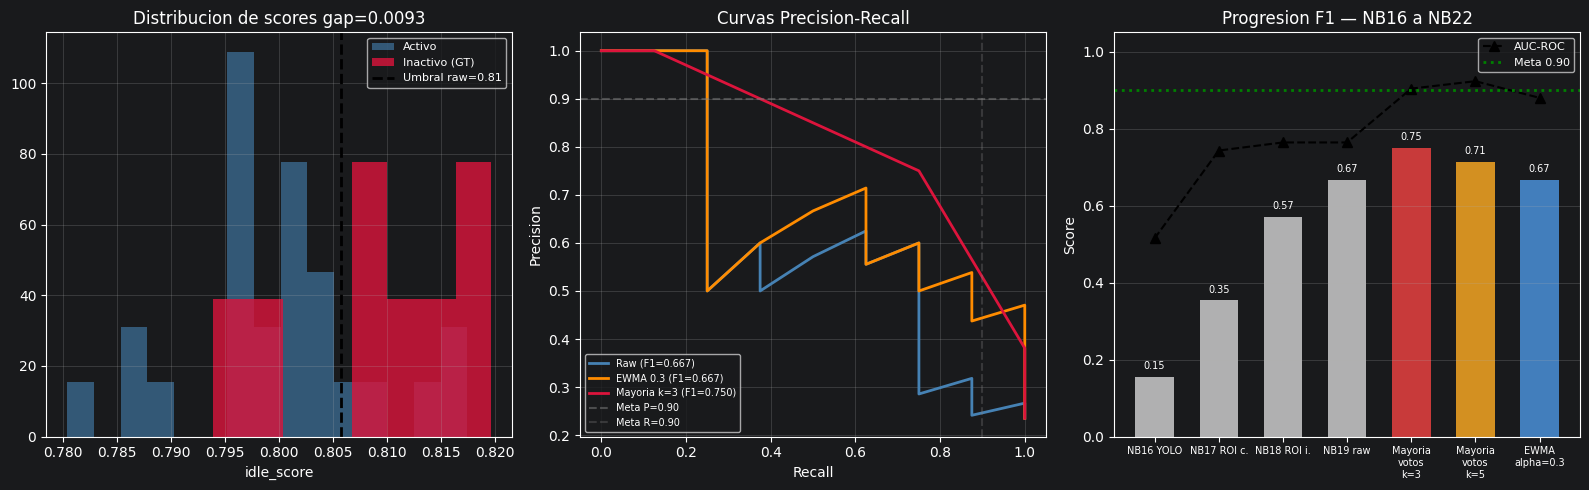

In [20]:
clips_idx = np.arange(len(gt_bin))
colors_gt = ["crimson" if g == 1 else "steelblue" for g in gt_bin]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: distribuciones de score
for col, (name, sc) in enumerate([("Raw NB10", score_nb10),
                                    ("EWMA 0.3", ewma(score_nb10, 0.3)),
                                    ("Mayoria k=3", majority_vote(score_nb10, 3, t_raw))]):
    if col > 0:
        break
    axes[0].hist(sc[gt_bin==0], bins=15, alpha=0.6, color="steelblue",
                 label="Activo", density=True)
    axes[0].hist(sc[gt_bin==1], bins=8,  alpha=0.8, color="crimson",
                 label="Inactivo (GT)", density=True)
    axes[0].axvline(t_raw, color="black", ls="--", lw=2, label=f"Umbral raw={t_raw:.2f}")
    axes[0].set_xlabel("idle_score")
    axes[0].set_title(f"Distribucion de scores gap={sc[gt_bin==1].mean()-sc[gt_bin==0].mean():.4f}")
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.3)

# Panel 2: curvas P-R
for name, sc, color in [
    (f"Raw (F1={results['Raw coseno (NB19)'][1]:.3f})", score_nb10, "steelblue"),
    (f"EWMA 0.3 (F1={results['EWMA alpha=0.3'][1]:.3f})", ewma(score_nb10, 0.3), "darkorange"),
    (f"Mayoria k=3 (F1={results['Mayoria votos k=3'][1]:.3f})",
     majority_vote(score_nb10, 3, t_raw), "crimson"),
]:
    prec, rec, _ = precision_recall_curve(gt_bin, sc)
    axes[1].plot(rec, prec, lw=2, label=name, color=color)
axes[1].axhline(0.9, ls="--", color="gray", alpha=0.5, label="Meta P=0.90")
axes[1].axvline(0.9, ls="--", color="gray", alpha=0.3, label="Meta R=0.90")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Curvas Precision-Recall")
axes[1].legend(fontsize=7)
axes[1].grid(alpha=0.3)

# Panel 3: progresión F1
prev     = [("NB16 YOLO",  0.155, 0.515),
            ("NB17 ROI c.", 0.354, 0.743),
            ("NB18 ROI i.", 0.571, 0.764),
            ("NB19 raw",   0.667, 0.764)]
curr_top = sorted([(k, v[1], v[4]) for k,v in results.items()
                   if k != "Raw coseno (NB19)"],
                  key=lambda x: -x[1])[:3]

all_labels = [r[0] for r in prev] + [r[0].replace(" ","\n") for r in curr_top]
all_f1s    = [r[1] for r in prev] + [r[1] for r in curr_top]
all_aucs   = [r[2] for r in prev] + [r[2] for r in curr_top]
all_colors = ["#ccc"]*4 + ["#E84040","#F5A623","#4A90D9"][:len(curr_top)]

x = np.arange(len(all_labels))
axes[2].bar(x, all_f1s, color=all_colors, alpha=0.85, width=0.6)
axes[2].plot(x, all_aucs, "k^--", lw=1.5, ms=7, label="AUC-ROC")
axes[2].axhline(0.9, ls=":", color="green", lw=2, label="Meta 0.90")
axes[2].set_xticks(x)
axes[2].set_xticklabels(all_labels, fontsize=7)
axes[2].set_ylabel("Score")
axes[2].set_ylim(0, 1.05)
axes[2].set_title("Progresion F1 — NB16 a NB22")
axes[2].legend(fontsize=8)
axes[2].grid(axis="y", alpha=0.3)
for bar, v in zip(axes[2].patches, all_f1s):
    axes[2].text(bar.get_x()+bar.get_width()/2, v+0.02,
                 f"{v:.2f}", ha="center", fontsize=7)

plt.tight_layout()
plt.savefig(OUTPUTS / "comparacion_metodos.png", dpi=130, bbox_inches="tight")
plt.show()


# 13. Timelines

Visualizamos cómo evolucionan los scores a lo largo de la secuencia de 34 clips. Los clips con fondo rojo son los GT idle — los 8 clips de "No action" de P05. El objetivo es ver que los scores de los clips rojos se diferencien claramente de los azules.


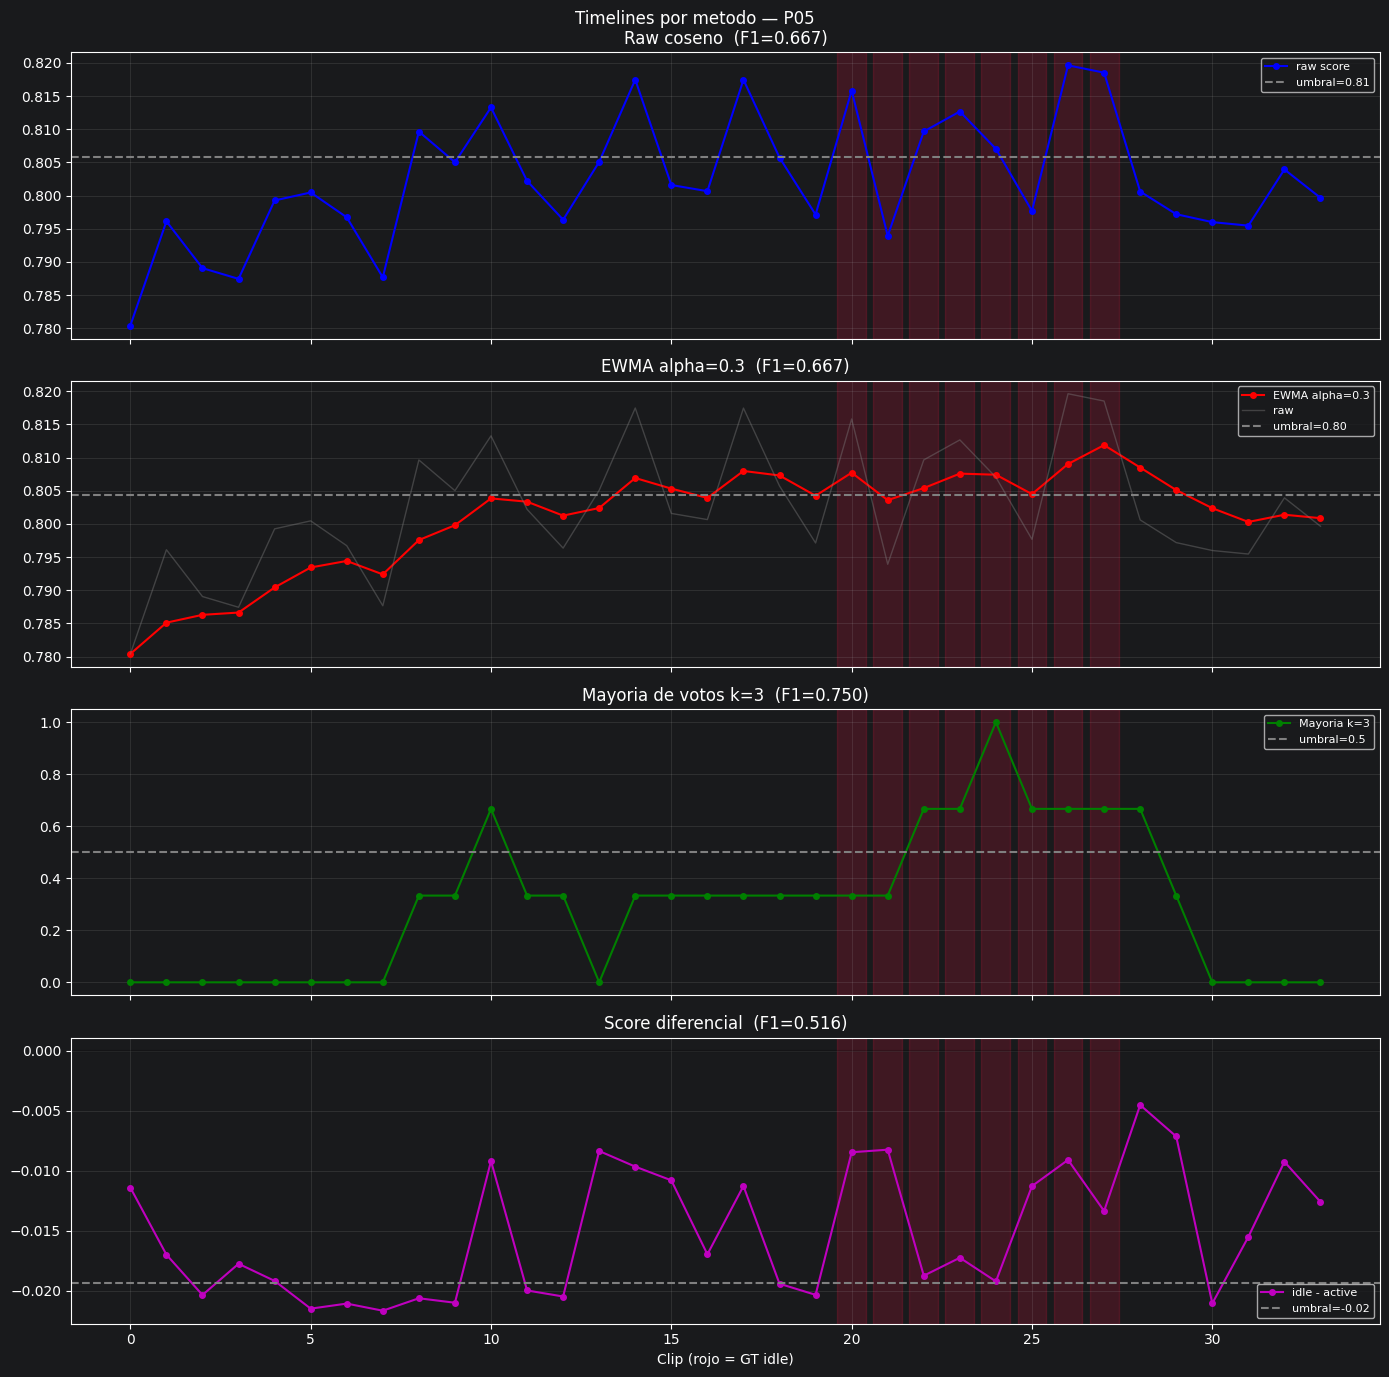

In [21]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
x = clips_idx

def shade_gt(ax):
    for i, g in enumerate(gt_bin):
        if g == 1:
            ax.axvspan(i-0.4, i+0.4, alpha=0.2, color="crimson", zorder=0)

# Raw
t_r = results["Raw coseno (NB19)"][0]
f1_r = results["Raw coseno (NB19)"][1]
axes[0].plot(x, score_nb10, "b-o", ms=4, lw=1.5, label="raw score")
axes[0].axhline(t_r, ls="--", color="gray", label=f"umbral={t_r:.2f}")
shade_gt(axes[0])
axes[0].set_title(f"Raw coseno  (F1={f1_r:.3f})")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.2)

# EWMA 0.3
sm_ew = ewma(score_nb10, 0.3)
t_ew  = results["EWMA alpha=0.3"][0]
f1_ew = results["EWMA alpha=0.3"][1]
axes[1].plot(x, sm_ew, "r-o", ms=4, lw=1.5, label="EWMA alpha=0.3")
axes[1].plot(x, score_nb10, "gray", lw=1, alpha=0.4, label="raw")
axes[1].axhline(t_ew, ls="--", color="gray", label=f"umbral={t_ew:.2f}")
shade_gt(axes[1])
axes[1].set_title(f"EWMA alpha=0.3  (F1={f1_ew:.3f})")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.2)

# Mayoria k=3
sm_mv = majority_vote(score_nb10, 3, t_raw)
t_mv  = results["Mayoria votos k=3"][0]
f1_mv = results["Mayoria votos k=3"][1]
axes[2].plot(x, sm_mv, "g-o", ms=4, lw=1.5, label="Mayoria k=3")
axes[2].axhline(0.5, ls="--", color="gray", label="umbral=0.5")
shade_gt(axes[2])
axes[2].set_title(f"Mayoria de votos k=3  (F1={f1_mv:.3f})")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.2)

# Diferencial
t_df  = results["Diferencial (idle-active)"][0]
f1_df = results["Diferencial (idle-active)"][1]
axes[3].plot(x, score_diff, "m-o", ms=4, lw=1.5, label="idle - active")
axes[3].axhline(t_df, ls="--", color="gray", label=f"umbral={t_df:.2f}")
axes[3].axhline(0, ls="-", color="black", alpha=0.2)
shade_gt(axes[3])
axes[3].set_title(f"Score diferencial  (F1={f1_df:.3f})")
axes[3].set_xlabel("Clip (rojo = GT idle)")
axes[3].legend(fontsize=8)
axes[3].grid(alpha=0.2)

plt.suptitle(f"Timelines por metodo — {PARTICIPANT}", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUTS / "timelines.png", dpi=130, bbox_inches="tight")
plt.show()


# 14. Resultados

Tabla de progresión completa desde varios experimentos previos hasta este, mostrando cómo cada decisión arquitectónica contribuyó a mejorar la detección de inactividad.


In [22]:
print(f"Participante:   {PARTICIPANT}")
print(f"GT inactivos:   {gt_bin.sum()} clips  |  GT activos: {(gt_bin==0).sum()}")
print()
print(f"{'Metodo':<32} {'F1':>6}  {'AUC':>6}")
print("-" * 50)

prev_results = [("NB16 YOLO crop",   0.155, 0.515),
                ("NB17 ROI central", 0.354, 0.743),
                ("NB18 ROI izq.",    0.571, 0.764),
                ("NB19 raw coseno",  0.667, 0.764)]
for lbl, f1, auc in prev_results:
    print(f"{lbl:<32} {f1:>6.3f}  {auc:>6.3f}")

print("-" * 50)
for method, (t, f1, p, r, auc) in sorted(results.items(), key=lambda x: -x[1][1]):
    label = f"NB22 {method}"
    print(f"{label:<32} {f1:>6.3f}  {auc:>6.3f}")

print()
print(f"Mejor metodo:  {best_method}")
print(f"F1:            {f1_best:.3f}")
print(f"AUC-ROC:       {auc_best:.3f}")
print(f"Precision:     {p_best:.3f}")
print(f"Recall:        {r_best:.3f}")


Participante:   P05
GT inactivos:   8 clips  |  GT activos: 26

Metodo                               F1     AUC
--------------------------------------------------
NB16 YOLO crop                    0.155   0.515
NB17 ROI central                  0.354   0.743
NB18 ROI izq.                     0.571   0.764
NB19 raw coseno                   0.667   0.764
--------------------------------------------------
NB22 Mayoria votos k=3            0.750   0.904
NB22 Mayoria votos k=5            0.714   0.923
NB22 Raw coseno (NB19)            0.667   0.764
NB22 EWMA alpha=0.3               0.667   0.880
NB22 EWMA alpha=0.7               0.667   0.812
NB22 EWMA alpha=0.5               0.625   0.832
NB22 Ventana media k=5            0.600   0.817
NB22 Ventana media k=3            0.593   0.755
NB22 Diferencial (idle-active)    0.516   0.673
NB22 Diferencial + EWMA 0.4       0.485   0.606

Mejor metodo:  Mayoria votos k=3
F1:            0.750
AUC-ROC:       0.904
Precision:     0.750
Recall:        0.

# 15. Ajuste de Umbral

Para ajustar el umbral sin volver a calcular los embeddings, modificar los parámetros de esta celda y re-ejecutarla.


In [ ]:
METODO    = "Mayoria votos k=3"   # nombre exacto de la tabla de resultados
THRESHOLD = 0.81

if METODO == "Mayoria votos k=3":
    sm = majority_vote(score_nb10, 3, THRESHOLD)
    pred = (sm >= 0.5).astype(int)
elif "EWMA" in METODO:
    alpha = float(METODO.split("=")[1])
    sm    = ewma(score_nb10, alpha)
    pred  = (sm >= THRESHOLD).astype(int)
else:
    pred = (score_nb10 >= THRESHOLD).astype(int)

p = precision_score(gt_bin, pred, zero_division=0)
r = recall_score(gt_bin, pred, zero_division=0)
f = f1_score(gt_bin, pred, zero_division=0)
print(f"Metodo={METODO}  Umbral={THRESHOLD:.2f}")
print(f"P={p:.3f}  R={r:.3f}  F1={f:.3f}")
